# Project #4: Risk Analysis 
**Team:** 151-05
**Date:** 2026-04-21

**Client:** Department of Homeland Security for the Federal Emergency Management Agency

In [7]:
## Import relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

from PIL import Image
from IPython.display import display

# Our Risk Score vs the NRI Lightning Risk Score in Colorado by County

In [9]:
co_nri = pd.read_csv("NRI_Table_CensusTracts.csv")
co_svi = pd.read_csv("Colorado.csv")
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

In [10]:
co_nri['STCNTY'] = co_nri['STCOFIPS']
co_nri.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=468)

In [11]:
complete_data = pd.merge(co_nri, co_svi, on = 'STCNTY')



In [13]:
complete_data = pd.merge(co_nri, co_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_data.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'EP_ASIAN', 'MP_ASIAN', 'EP_AIAN', 'MP_AIAN', 'EP_NHPI', 'MP_NHPI',
       'EP_TWOMORE', 'MP_TWOMORE', 'EP_OTHERRACE', 'MP_OTHERRACE'],
      dtype='object', length=625)

In [14]:

complete_data['CALC_LTNG_RISK'] = (
    (complete_data['LTNG_EALS'] * 0.40) +
    (complete_data['SOVI_SCORE'] * 0.45) +
    ((1 - complete_data['RESL_SCORE']) * 0.15)
)


In [15]:

# Ensure numeric
complete_data["CALC_LTNG_RISK"] = pd.to_numeric(complete_data["CALC_LTNG_RISK"], errors="coerce")
complete_data["LTNG_RISKS"] = pd.to_numeric(complete_data["LTNG_RISKS"], errors="coerce")

# Clean county names
complete_data["COUNTY"] = complete_data["COUNTY"].str.strip()

# Group and compute means
grouped_data = complete_data.groupby("COUNTY").agg(
    ang_my_lntg_risk=("CALC_LTNG_RISK", "mean"),
    avg_lntg_NRI=("LTNG_RISKS", "mean")
)

print(grouped_data.head())

           ang_my_lntg_risk  avg_lntg_NRI
COUNTY                                   
Adams             40.146068     72.546994
Alamosa           67.224011     93.113814
Arapahoe          38.997687     68.977721
Archuleta         65.397622     92.021690
Baca              79.189205     99.230614


In [16]:
### Group your data by county
grouped_data = complete_data.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data = complete_data.groupby('COUNTY').agg(avg_my_lntg_risk=('CALC_LTNG_RISK', 'mean'), 
                                                   avg_lntg_NRI=('LTNG_RISKS', 'mean'))

print(grouped_data)

            avg_my_lntg_risk  avg_lntg_NRI
COUNTY                                    
Adams              40.146068     72.546994
Alamosa            67.224011     93.113814
Arapahoe           38.997687     68.977721
Archuleta          65.397622     92.021690
Baca               79.189205     99.230614
...                      ...           ...
Summit             44.582465     93.512837
Teller             51.966946     99.047929
Washington         47.706029     57.053500
Weld               33.121324     60.339621
Yuma               48.404376     92.249058

[64 rows x 2 columns]


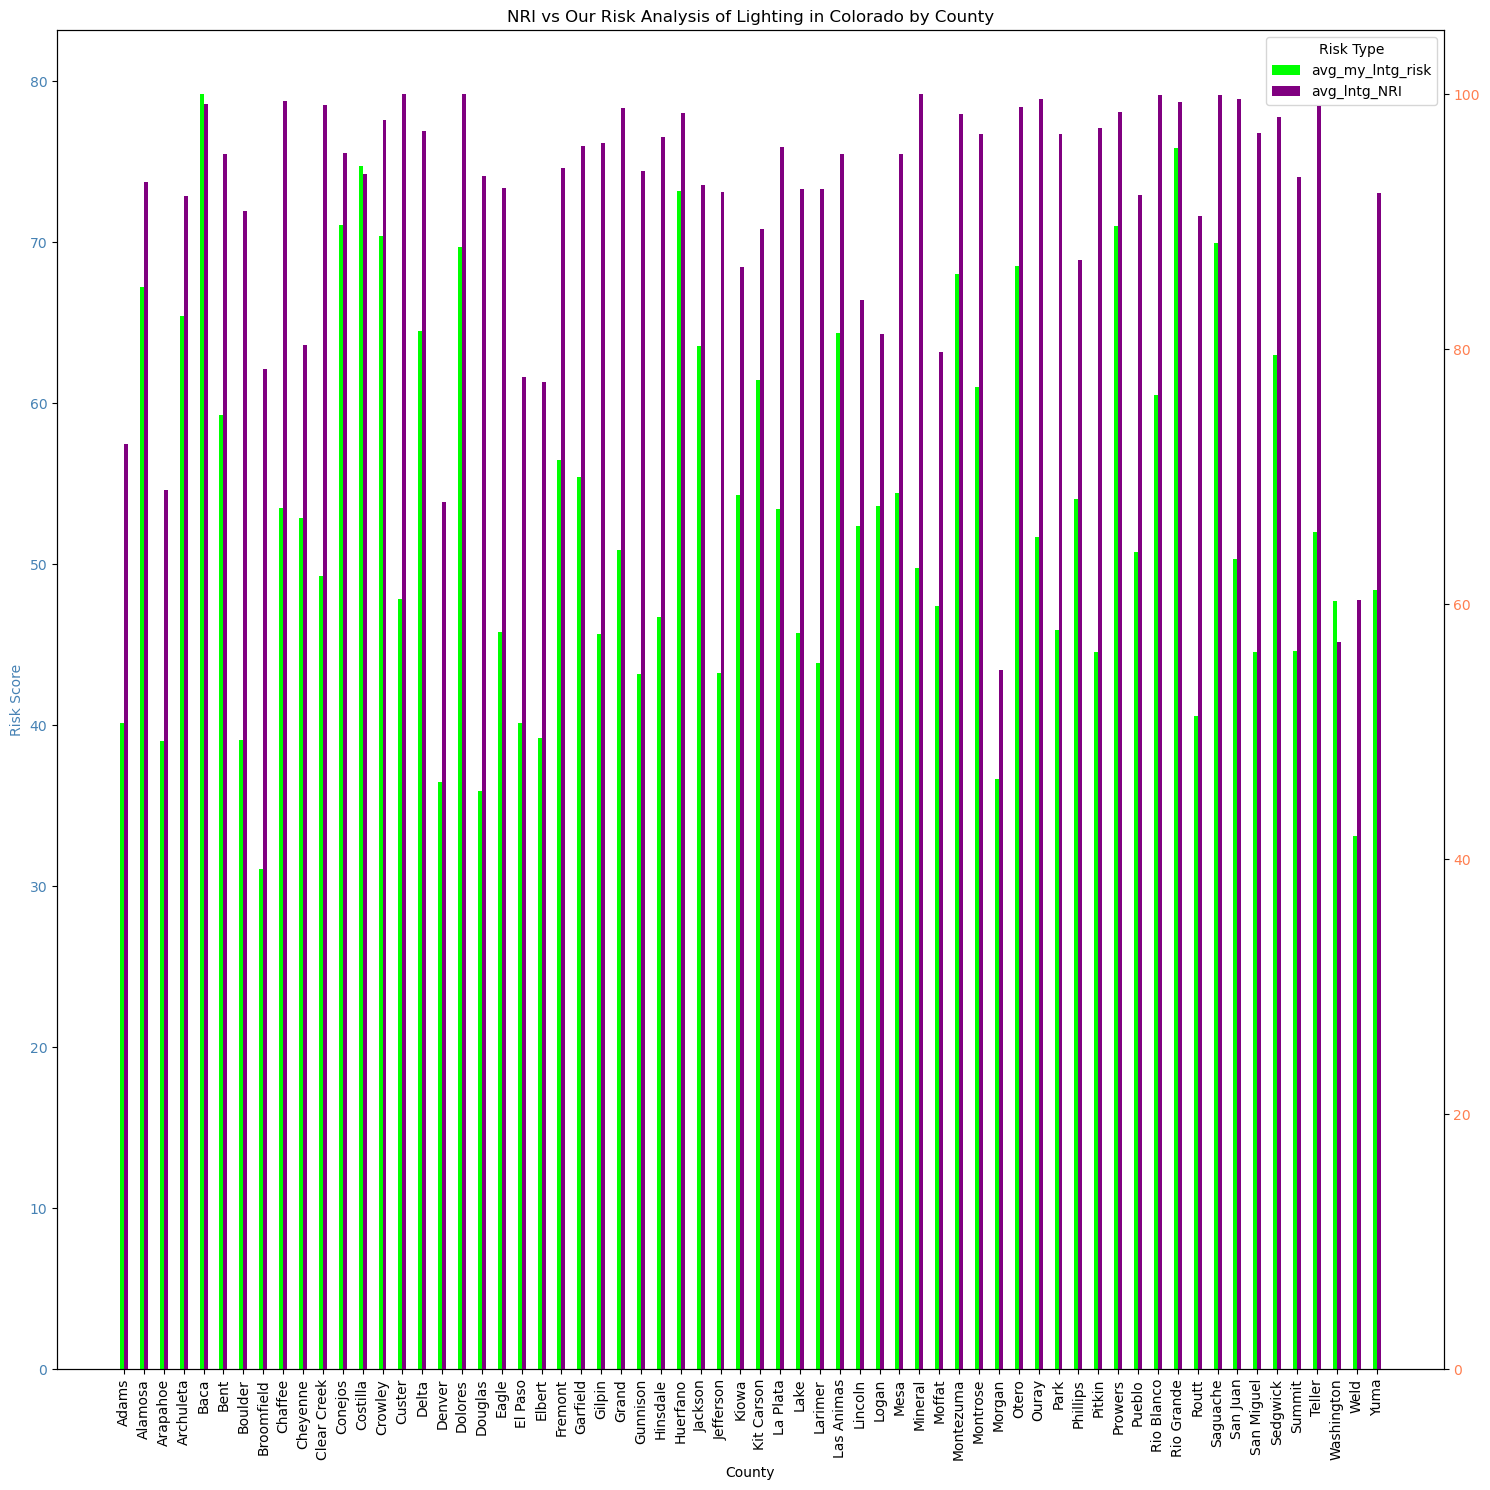

In [17]:
fig, ax1 = plt.subplots(figsize=(15,15))

x = range(len(grouped_data))
width = 0.2
ax1.bar([i-width/2 for i in x], grouped_data.iloc[:, 0], width=width, color ='lime', label=grouped_data.columns[0])
ax1.set_ylabel('Risk Score', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], grouped_data.iloc[:, 1], width=width, color='purple', label=grouped_data.columns[1])
ax2.tick_params(axis = 'y', labelcolor = 'coral')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_data.index, rotation = 90)
ax1.set_xlabel('County')

plt.title('NRI vs Our Risk Analysis of Lighting in Colorado by County')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title = 'Risk Type')

plt.tight_layout()
plt.show()

# Our Risk Score vs the NRI Winter Weather Risk in Colorado by County

In [19]:

complete_data['CALC_WNTW_RISK'] = (
    (complete_data['WNTW_EALS'] * 0.40) +
    (complete_data['SOVI_SCORE'] * 0.45) +
    ((1 - complete_data['RESL_SCORE']) * 0.15)
)


In [20]:
### Group your data by county
grouped_data = complete_data.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data = complete_data.groupby('COUNTY').agg(avg_my_wntw_risk=('CALC_WNTW_RISK', 'mean'), 
                                                   avg_wntw_NRI=('WNTW_RISKS', 'mean'))

print(grouped_data)

            avg_my_wntw_risk  avg_wntw_NRI
COUNTY                                    
Adams              43.607044     82.400256
Alamosa            61.349761     80.659938
Arapahoe           31.997727     51.840058
Archuleta          64.713773     90.203177
Baca               76.942273     95.976977
...                      ...           ...
Summit             42.138729     87.214450
Teller             50.374554     94.647837
Washington         64.714901     93.590691
Weld               37.900609     72.662187
Yuma               49.967788     98.643302

[64 rows x 2 columns]


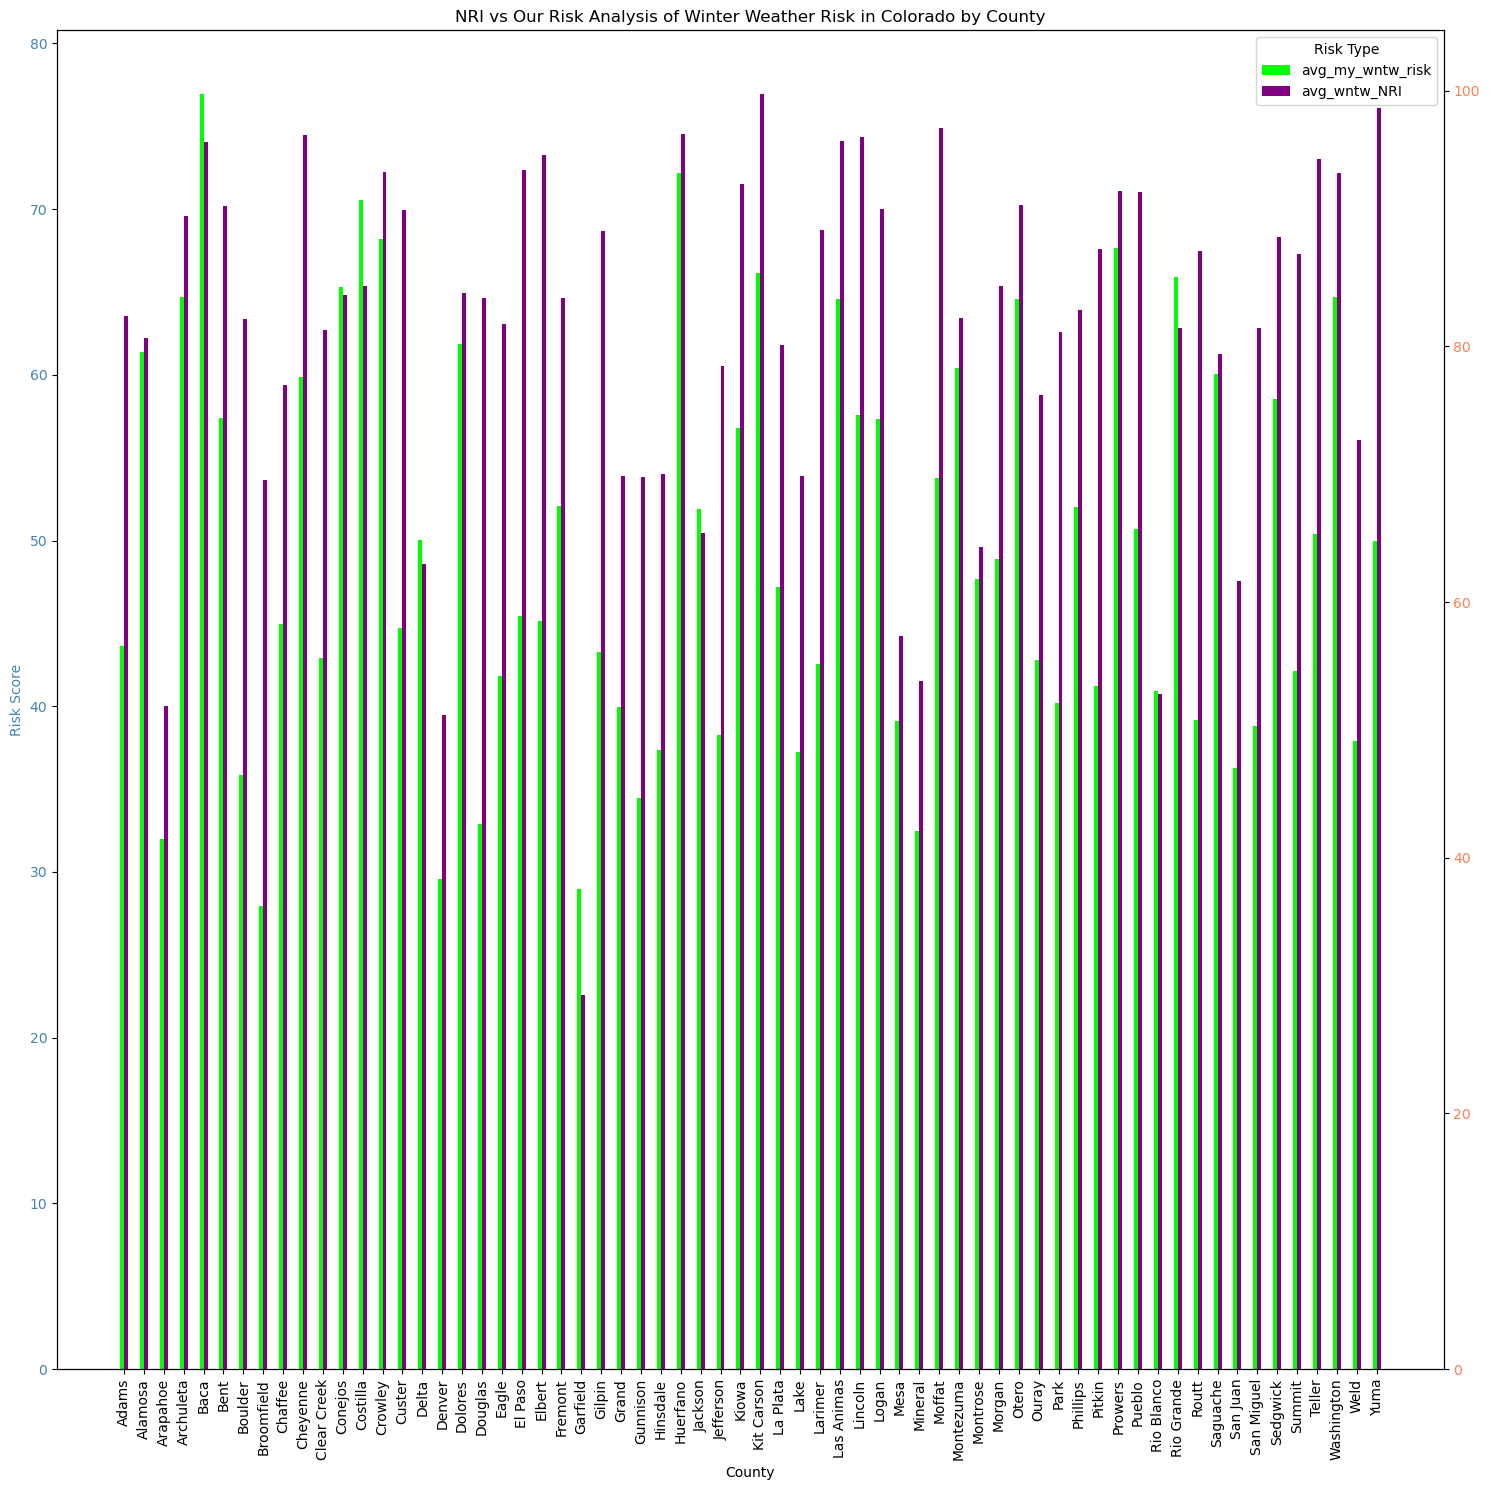

In [21]:
fig, ax1 = plt.subplots(figsize=(15,15))

x = range(len(grouped_data))
width = 0.2
ax1.bar([i-width/2 for i in x], grouped_data.iloc[:, 0], width=width, color ='lime', label=grouped_data.columns[0])
ax1.set_ylabel('Risk Score', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], grouped_data.iloc[:, 1], width=width, color='purple', label=grouped_data.columns[1])
ax2.tick_params(axis = 'y', labelcolor = 'coral')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_data.index, rotation = 90)
ax1.set_xlabel('County')

plt.title('NRI vs Our Risk Analysis of Winter Weather Risk in Colorado by County')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title = 'Risk Type')

plt.tight_layout()
plt.show()

# Our Risk Score vs the NRI Heat Wave Risk Score in Texas by County

In [26]:
tx_nri = pd.read_csv("NRI_Table_CensusTracts.csv", low_memory = False)
tx_svi = pd.read_csv("Texas.tracts.csv", low_memory = False)
nri_dictionary = pd.read_csv("NRIDataDictionary.csv")

tx_nri.columns = tx_nri.columns.str.strip().str.upper()
tx_svi.columns = tx_svi.columns.str.strip().str.upper()

print(tx_nri.columns.tolist())
print(tx_svi.columns.tolist())



['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY', 'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT', 'TRACTFIPS', 'POPULATION', 'BUILDVALUE', 'AGRIVALUE', 'AREA', 'RISK_VALUE', 'RISK_SCORE', 'RISK_RATNG', 'RISK_SPCTL', 'EAL_SCORE', 'EAL_RATNG', 'EAL_SPCTL', 'EAL_VALT', 'EAL_VALB', 'EAL_VALP', 'EAL_VALPE', 'EAL_VALA', 'ALR_VALB', 'ALR_VALP', 'ALR_VALA', 'ALR_NPCTL', 'ALR_VRA_NPCTL', 'SOVI_SCORE', 'SOVI_RATNG', 'SOVI_SPCTL', 'RESL_SCORE', 'RESL_RATNG', 'RESL_SPCTL', 'RESL_VALUE', 'CRF_VALUE', 'AVLN_EVNTS', 'AVLN_AFREQ', 'AVLN_EXP_AREA', 'AVLN_EXPB', 'AVLN_EXPP', 'AVLN_EXPPE', 'AVLN_EXPT', 'AVLN_HLRB', 'AVLN_HLRP', 'AVLN_HLRR', 'AVLN_EALB', 'AVLN_EALP', 'AVLN_EALPE', 'AVLN_EALT', 'AVLN_EALS', 'AVLN_EALR', 'AVLN_ALRB', 'AVLN_ALRP', 'AVLN_ALR_NPCTL', 'AVLN_RISKV', 'AVLN_RISKS', 'AVLN_RISKR', 'CFLD_EVNTS', 'CFLD_AFREQ', 'CFLD_EXP_AREA', 'CFLD_EXPB', 'CFLD_EXPP', 'CFLD_EXPPE', 'CFLD_EXPT', 'CFLD_HLRB', 'CFLD_HLRP', 'CFLD_HLRR', 'CFLD_EALB', 'CFLD_EALP', 'CFLD_EALPE', 'CFLD_EALT',

In [31]:
tx_nri['STCNTY'] = tx_nri['STCOFIPS']
tx_svi['STCNTY'] = tx_nri['STCOFIPS']
tx_nri.columns

Index(['OID_', 'NRI_ID', 'STATE', 'STATEABBRV', 'STATEFIPS', 'COUNTY',
       'COUNTYTYPE', 'COUNTYFIPS', 'STCOFIPS', 'TRACT',
       ...
       'WNTW_EALR', 'WNTW_ALRB', 'WNTW_ALRP', 'WNTW_ALRA', 'WNTW_ALR_NPCTL',
       'WNTW_RISKV', 'WNTW_RISKS', 'WNTW_RISKR', 'NRI_VER', 'STCNTY'],
      dtype='object', length=468)

In [ ]:
complete_data_tx = pd.merge(tx_nri, tx_svi, on = 'STCNTY')

In [ ]:
complete_data_tx = pd.merge(tx_nri, tx_svi, on = 'STCNTY', suffixes=('', '_right'))
complete_data_tx.columns

In [ ]:

complete_data_tx['CALC_HWAV_RISK'] = (
    (complete_data_tx['HWAV_EALS'] * 0.40) +
    (complete_data_tx['SOVI_SCORE'] * 0.45) +
    ((1 - complete_data_tx['RESL_SCORE']) * 0.15)
)


In [ ]:
### Group your data by county
grouped_data_tx = complete_data_tx.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data_tx = complete_data_tx.groupby('COUNTY').agg(mean_hwav_my_risk=('CALC_HWAV_RISK', 'mean'), 
                                                   mean_hwav_NRI=('HWAV_RISKS', 'mean'))

print(grouped_data_tx)

In [ ]:
fig, ax1 = plt.subplots(figsize=(50,30))

x = range(len(grouped_data_tx))
width = 0.6
ax1.bar([i-width/2 for i in x], grouped_data_tx.iloc[:, 0], width=width, color ='lime', label=grouped_data_tx.columns[0])
ax1.set_ylabel('Risk Score', color='lime', fontsize = 20)
ax1.tick_params(axis='y', labelcolor='lime')

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], grouped_data_tx.iloc[:, 1], width=width, color='purple', label=grouped_data_tx.columns[1])
ax2.tick_params(axis = 'y', labelcolor = 'purple')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_data_tx.index, rotation = 90)
ax1.set_xlabel('County', fontsize = 20)

plt.title('NRI vs Our Risk Analysis of Heat Waves in Texas by County', fontsize = 30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title = 'Risk Type')

plt.tight_layout()
plt.show()

# Our Risk Score vs the NRI Tornado Risk Score in Texas by County

In [ ]:

complete_data_tx['CALC_TRND_RISK'] = (
    (complete_data_tx['TRND_EALS'] * 0.40) +
    (complete_data_tx['SOVI_SCORE'] * 0.45) +
    ((1 - complete_data_tx['RESL_SCORE']) * 0.15)
)


In [ ]:
### Group your data by county
grouped_data_tx = complete_data_tx.groupby('COUNTY',as_index=False)

## Run summary mean by county
grouped_data_tx = complete_data_tx.groupby('COUNTY').agg(mean_trnd_my_risk=('CALC_TRND_RISK', 'mean'), 
                                                   mean_trnd_NRI=('TRND_RISKS', 'mean'))

print(grouped_data_tx)

In [ ]:
fig, ax1 = plt.subplots(figsize=(50,30))

x = range(len(grouped_data_tx))
width = 0.6
ax1.bar([i-width/2 for i in x], grouped_data_tx.iloc[:, 0], width=width, color ='steelblue', label=grouped_data_tx.columns[0])
ax1.set_ylabel('Risk Score', color='steelblue', fontsize = 20)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2 = ax1.twinx()
ax2.bar([i + width/2 for i in x], grouped_data_tx.iloc[:, 1], width=width, color='coral', label=grouped_data_tx.columns[1])
ax2.tick_params(axis = 'y', labelcolor = 'coral')

ax1.set_xticks(x)
ax1.set_xticklabels(grouped_data_tx.index, rotation = 90)
ax1.set_xlabel('County', fontsize = 20)

plt.title('NRI vs Our Risk Analysis of Tornados in Texas by County', fontsize = 30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, title = 'Risk Type')

plt.tight_layout()
plt.show()

# Geopanda Map for Colorado Showing NRI and Our Risk Scores for Lightning by County

In [ ]:
## Read the Census Tracts data
tracts = gpd.read_file('NRI_Shapefile_CensusTracts.shp')

##Verifications for Shape files
tracts.head()

###This checks for Coordinate Reference System (CRS)
tracts.crs
###Checks the geometries in the data
tracts.geometry.head()

In [ ]:
### Cleaning data - Dr. Lane's Example

# Check the projection and set it
tracts_clean = tracts.set_crs(epsg = 4326, inplace = True, allow_override=True)

# 3. Now you can transform to a new CRS (e.g., Pseudo-Mercator)
tracts_clean = tracts_clean.to_crs(epsg = 4326)

# Replace -9999 nulls with NaN

tracts_clean = tracts_clean.replace(-9999, np.nan)

In [ ]:
# 1. Tell GeoPandas the data is actually Web Mercator (meters)
tracts_clean.crs = 'EPSG:3857'

# 2. Now properly convert it to degrees to match your xlim/ylim
tracts_clean = tracts_clean.to_crs(epsg=4326)

# Standard projection for US National maps

tracts_clean = tracts_clean.to_crs('ESRI:102003')

tracts_clean.head()

In [ ]:
state_name = 'Colorado' 

state_map = tracts_clean[tracts_clean['STATE'] == state_name]
state_map

### Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column='LTNG_RISKS',
    cmap='RdYlBu_r',
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)

# 5. Final styling
ax.set_title('National Risk Index Score for Colorado', fontsize = 16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


state_name = 'Colorado' 

state_map = tracts_clean[tracts_clean['STATE'] == state_name]
state_map

state_map['CALC_LTNG_RISK'] = (
    (state_map['LTNG_EALS'] * 0.40) +
    (state_map['SOVI_SCORE'] * 0.45) +
    ((1 - state_map['RESL_SCORE']) * 0.15)
)
### Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column='CALC_LTNG_RISK',
    cmap='RdYlBu_r',
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)

# 5. Final styling
ax.set_title('Lightning Score for Colorado', fontsize = 16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


# Geopanda Map for Texas Showing NRI and Our Risk Scores for Heat Wave by County

In [ ]:
state_name = 'Texas' 

state_map = tracts_clean[tracts_clean['STATE'] == state_name]
state_map

### Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(14, 10))

state_map.plot(
    column='HWAV_RISKS',
    cmap='RdYlBu_r',
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)

# 5. Final styling
ax.set_title('National Risk Index Score for Texas', fontsize = 16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()


state_name = 'Texas' 

state_map = tracts_clean[tracts_clean['STATE'] == state_name]
state_map

state_map['CALC_HWAV_RISK'] = (
    (state_map['HWAV_EALS'] * 0.40) +
    (state_map['SOVI_SCORE'] * 0.45) +
    ((1 - state_map['RESL_SCORE']) * 0.15)
)
### Setup the plot
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

state_map.plot(
    column='CALC_HWAV_RISK',
    cmap='RdYlBu_r',
    aspect = 1,
    linewidth=0.0,
    ax=ax,
    legend=True,
    legend_kwds={'label': 'Risk Score (0-100)', 'orientation': 'horizontal', 'shrink': 0.6, 'pad': 0.05},
    missing_kwds={'color': 'lightgrey', 'label': 'No Data'},
)

# 5. Final styling
ax.set_title('Heatwave Score for Texas', fontsize = 16, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.show()
